<a href="https://colab.research.google.com/github/jpcampos04/2605_leaf_diseases_cv/blob/main/2605_leaf_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introdution

The purpose of this project is to create a predictive computer vision model who can predict diseases from tomatoes leaf images.

A project like this can help in the agriculture sector to prevent diseases from spreading around healthy crops and keep a sustainable production in this case of tomatoes.

## Preparation

In [ ]:
!pip install kaggle -q

In [ ]:
# Import libraries
import os # Interact with operating system
import json # Create json file

import zipfile # Unzip files

In [ ]:
# Connect with API
# Username information
kaggle_username = "jospablocampos"
kaggel_key = "KGAT_2f7b42da721d37af2975e06badb9aaf0"

# Create kaggle.json file
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Dictionary with username infomation for .json file
kaggle_credentials = {
    "username": kaggle_username,
    "key": kaggle_key
}

kaggle_path = os.path.expanduser("~/.kaggle/kaggle.json")

with open(kaggle_path, "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod(kaggle_path, 0o600)

print("Credentials correctly setup")

✅ Credenciales configuradas correctamente


In [1]:
# Path to dataset
dataset = "yusufmurtaza01/tomato-leaf-disease"

!kaggle datasets download -d {dataset} --path /content/data
print("Download completed")

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/tomato-leaf-disease
License(s): CC0-1.0
100% 445M/445M [00:06<00:00, 75.9MB/s]

✅ Descarga completa


In [ ]:
# Root
zip_path = "/content/data"

# Unzip .zip files founded
for file in os.listdir(zip_path): # Loop for to unzip file
    if f.endswith(".zip"):
        full_path = os.path.join(zip_path, file)
        print(f"Decompressing {file}...")
        with zipfile.ZipFile(full_path, "r") as zip_ref:
            zip_ref.extractall(zip_path)
        print(f"{file} decompressed")

# Show decompressed file structure
for root, dirs, files in os.walk(zip_path):
    level = root.replace(zip_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for file in files[:5]:  # Show first 5 files in folder
            print(f"{indent}  {file}")

Descomprimiendo tomato-leaf-disease.zip...
✅ tomato-leaf-disease.zip descomprimido
data/
  Labels_Counts.png
  tomato-leaf-disease.zip
  Images_Counts.png
  tomato/
    data.yaml
    labels/
      train/
      val/
    images/
      train/
      val/


In [ ]:
# Import libraries
import pandas as pd
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verify GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU disponible: []


## Classes and Distributions

In [ ]:
# Show the diseases classes
import yaml # For cleaner syntax

with open("/content/data/tomato/data.yaml", "r") as file:
    config = yaml.safe_load(file)

# List to store diseases classes
class_names = config["names"]
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

Número de clases: 10
Clases: ['Tomato__BacterialSpot', 'Tomato__EarlyBlight', 'Tomato__Healthy', 'Tomato__LateBlight', 'Tomato__LeafMold', 'Tomato__MosaicVirus', 'Tomato__SeptoriaLeafSpot', 'Tomato__SpiderMites', 'Tomato__TargetSpot', 'Tomato__YellowLeafCurlVirus']


In [ ]:
# Define function to split train and validation sets by classes
def build_dataframe(split):
    images_dir = Path(f"/content/data/tomato/images/{split}")
    labels_dir = Path(f"/content/data/tomato/labels/{split}")

    records = []
    for img_path in images_dir.iterdir():
        label_path = labels_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path) as file:
                first_line = file.readline().strip()
                if first_line:
                    class_idx = int(first_line.split()[0])
                    records.append({
                        "image_path": str(img_path),
                        "class_idx": class_idx,
                        "class_name": class_names[class_idx]
                    })

    return pd.DataFrame(records)

df_train = build_dataframe("train")
df_val   = build_dataframe("val")

print(f"Train: {len(df_train)} images")
print(f"Val:   {len(df_val)} images")
print("\nClasses distribution (train):")
print(df_train["class_name"].value_counts())

Train: 12168 imágenes
Val:   3041 imágenes

Distribución de clases (train):
class_name
Tomato__YellowLeafCurlVirus    1600
Tomato__LateBlight             1599
Tomato__BacterialSpot          1598
Tomato__SeptoriaLeafSpot       1536
Tomato__SpiderMites            1343
Tomato__Healthy                1322
Tomato__TargetSpot             1124
Tomato__EarlyBlight             870
Tomato__LeafMold                834
Tomato__MosaicVirus             342
Name: count, dtype: int64


- As we can see there are 3 diseases that are underrepresented in the hole dataset.

## Modeling

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

img_size = (224, 224)
batch_size = 32

# Define function to make datasets
def make_dataset(df, shuffle=False):
    paths  = df["image_path"].values
    labels = tf.keras.utils.to_categorical(df["class_idx"].values, num_classes)

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = preprocess_input(img)  # Standarization for EfficientNet
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Execute funtion to make datasets
train_ds = make_dataset(df_train, shuffle=True)
val_ds   = make_dataset(df_val,   shuffle=False)

print("Datasets done")

✅ Datasets listos


In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

# Base pretrain in ImageNet
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Frezzed to keep light the model

# Inputs and outputs of clasification
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Store Model
model = Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [2]:
# Balance the clasess
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df_train["class_idx"]),
    y=df_train["class_idx"]
)

class_weight_dict = dict(enumerate(class_weights_array))

print("Weights by class:")
for idx, weight in class_weight_dict.items():
    print(f"  {class_names[idx]:<35} → {weight:.3f}")

NameError: name 'np' is not defined

- Higher weights by class are for the underrepresented diseases images to balance the sample.

In [ ]:
# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
    ]
)

Epoch 1/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1158s 3s/step - accuracy: 0.6786 - loss: 1.1189 - val_accuracy: 0.8448 - val_loss: 0.6304 - learning_rate: 0.0010
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1105s 3s/step - accuracy: 0.8254 - loss: 0.6263 - val_accuracy: 0.8750 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.8557 - loss: 0.5134 - val_accuracy: 0.8938 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1149s 3s/step - accuracy: 0.8697 - loss: 0.4541 - val_accuracy: 0.8987 - val_loss: 0.3584 - learning_rate: 0.0010
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1125s 3s/step - accuracy: 0.8772 - loss: 0.4151 - val_accuracy: 0.9037 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1079s 3s/step - accuracy: 0.8845 - loss: 0.3933 - val_accuracy: 0.9115 - val_loss: 0.3214 - learning_rate: 0.0010
Epoch 7/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1125s 3s/step - accuracy: 0.8825 - l

- Validation dataset improve regarding training dataset with every new epoch avoiding an Earlystopping.

In [ ]:
# Use the base model to see if it improves
# Unfrezzed last 30 layers of EfficientNetB0
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # 100x lower than before
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params now: {trainable_count:,}")

Parámetros entrenables ahora: 1,508,970


In [ ]:
# Retrain model with more params
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
    ]
)

Epoch 1/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1308s 3s/step - accuracy: 0.7924 - loss: 0.6414 - val_accuracy: 0.8912 - val_loss: 0.3612 - learning_rate: 1.0000e-05
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1292s 3s/step - accuracy: 0.8457 - loss: 0.4819 - val_accuracy: 0.9063 - val_loss: 0.3114 - learning_rate: 1.0000e-05
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1241s 3s/step - accuracy: 0.8668 - loss: 0.4050 - val_accuracy: 0.9142 - val_loss: 0.2755 - learning_rate: 1.0000e-05
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1292s 3s/step - accuracy: 0.8813 - loss: 0.3645 - val_accuracy: 0.9234 - val_loss: 0.2512 - learning_rate: 1.0000e-05
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1294s 3s/step - accuracy: 0.8889 - loss: 0.3350 - val_accuracy: 0.9296 - val_loss: 0.2312 - learning_rate: 1.0000e-05
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1289s 3s/step - accuracy: 0.9057 - loss: 0.2909 - val_accuracy: 0.9342 - val_loss: 0.2170 - learning_rate: 1.0000e-05
Epoch 7/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1292s 3s/ste

- Accuracy improve from 92.6% with 12,810 params to 94.5% with 1,508,970 params.

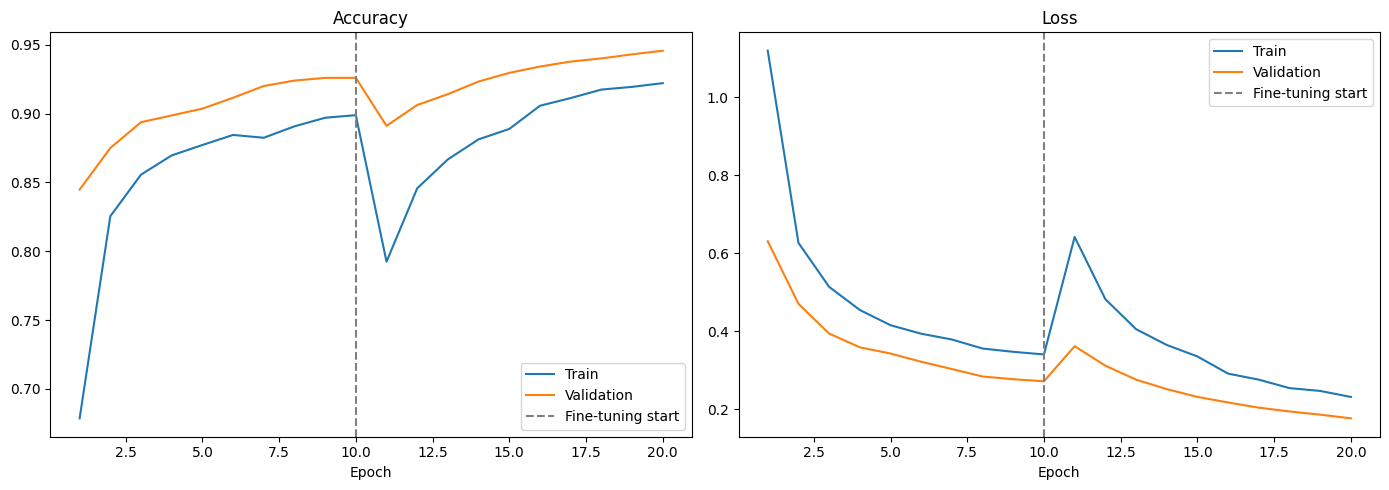

✅ Gráfica guardada


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot results form both phases
acc     = history.history["accuracy"]     + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss    = history.history["loss"]         + history_ft.history["loss"]
val_loss= history.history["val_loss"]     + history_ft.history["val_loss"]

epochs_total = range(1, len(acc) + 1)
fine_tune_start = len(history.history["accuracy"])

for ax, train_m, val_m, title in zip(
    axes,
    [acc, loss],
    [val_acc, val_loss],
    ["Accuracy", "Loss"]
):
    ax.plot(epochs_total, train_m, label="Train")
    ax.plot(epochs_total, val_m, label="Validation")
    ax.axvline(fine_tune_start, color="gray", linestyle="--", label="Fine-tuning start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.savefig("/content/data/training_curves.png", dpi=150)
plt.show()
print("Graph saved")

- In order to visualize where is the model making mistakes a confusion matrix is needed.

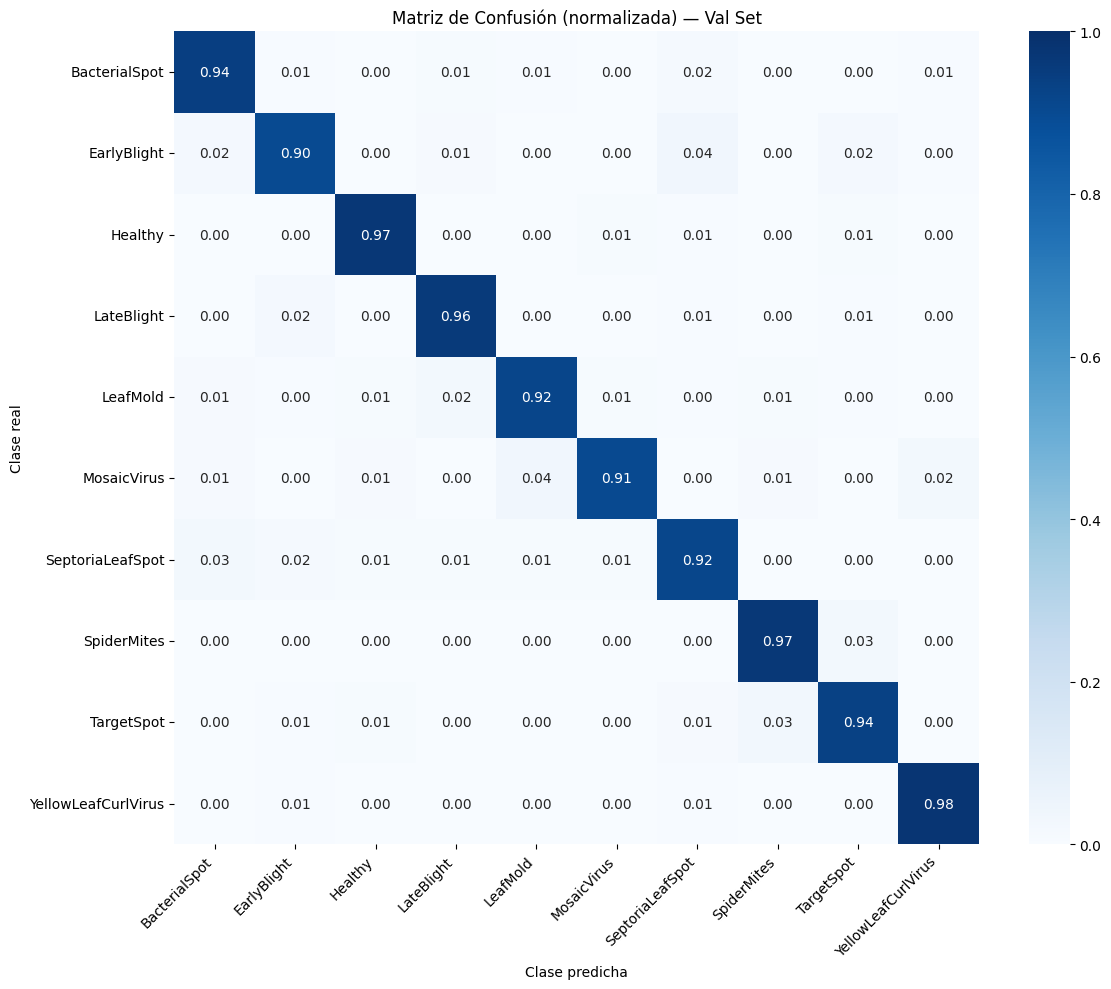


Classification Report:
                     precision    recall  f1-score   support

      BacterialSpot       0.95      0.94      0.95       400
        EarlyBlight       0.89      0.90      0.89       218
            Healthy       0.97      0.97      0.97       332
         LateBlight       0.96      0.96      0.96       400
           LeafMold       0.93      0.92      0.92       208
        MosaicVirus       0.86      0.91      0.88        85
   SeptoriaLeafSpot       0.93      0.92      0.92       383
        SpiderMites       0.96      0.97      0.96       335
         TargetSpot       0.92      0.94      0.93       280
YellowLeafCurlVirus       0.98      0.98      0.98       400

           accuracy                           0.95      3041
          macro avg       0.94      0.94      0.94      3041
       weighted avg       0.95      0.95      0.95      3041



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Empty lists to store predictions
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)  # Normalizada

# Short names to use in graph
short_names = [c.replace("Tomato__", "") for c in class_names]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f",
    xticklabels=short_names,
    yticklabels=short_names,
    cmap="Blues",
    vmin=0, vmax=1
)
plt.title("Confusion Matrix (normalized) — Val Set")
plt.ylabel("Actual class")
plt.xlabel("Predicted class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/data/confusion_matrix.png", dpi=150)
plt.show()

# Reporte por clase
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=short_names))

- Predictions are consistent even in the underrepresented classes like Mosaic Virus where there were fewer images

In [ ]:
# Define funtion to generate heatmap

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    """Generate heatmap Grad-CAM for an image."""

    # Model which returns activations from las conv layer + final prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer("efficientnetb0").get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradients regarding the convoutional layer
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay heatmap on top of original image."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, superimposed


print("Defined Grad-CAM functions")

✅ Funciones Grad-CAM definidas


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_238']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m135262524079040\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[139., 135., 136.],\n         [146., 142., 143.],\n         [147., 143., 144.],\n         ...,\n         [133., 127., 127.],\n         [137., 131., 131.],\n         [147., 141., 141.]],\n\n        [[133., 129., 130.],\n         [138., 134., 135.],\n         [138., 134., 135.],\n         ...,\n         [134., 128., 128.],\n         [136., 130., 130.],\n         [141., 135., 135.]],\n\n        [[139., 135., 136.],\n         [141., 137., 138.],\n         [138., 134., 135.],\n         ...,\n         [138., 132., 132.],\n         [137., 131., 131.],\n         [137., 131., 131.]],\n\n        ...,\n\n        [[150., 148., 151.],\n         [149., 147., 150.],\n         [146., 144., 147.],\n         ...,\n         [155., 151., 152.],\n         [155., 151., 152.],\n         [155., 151., 152.]],\n\n        [[148., 146., 149.],\n        

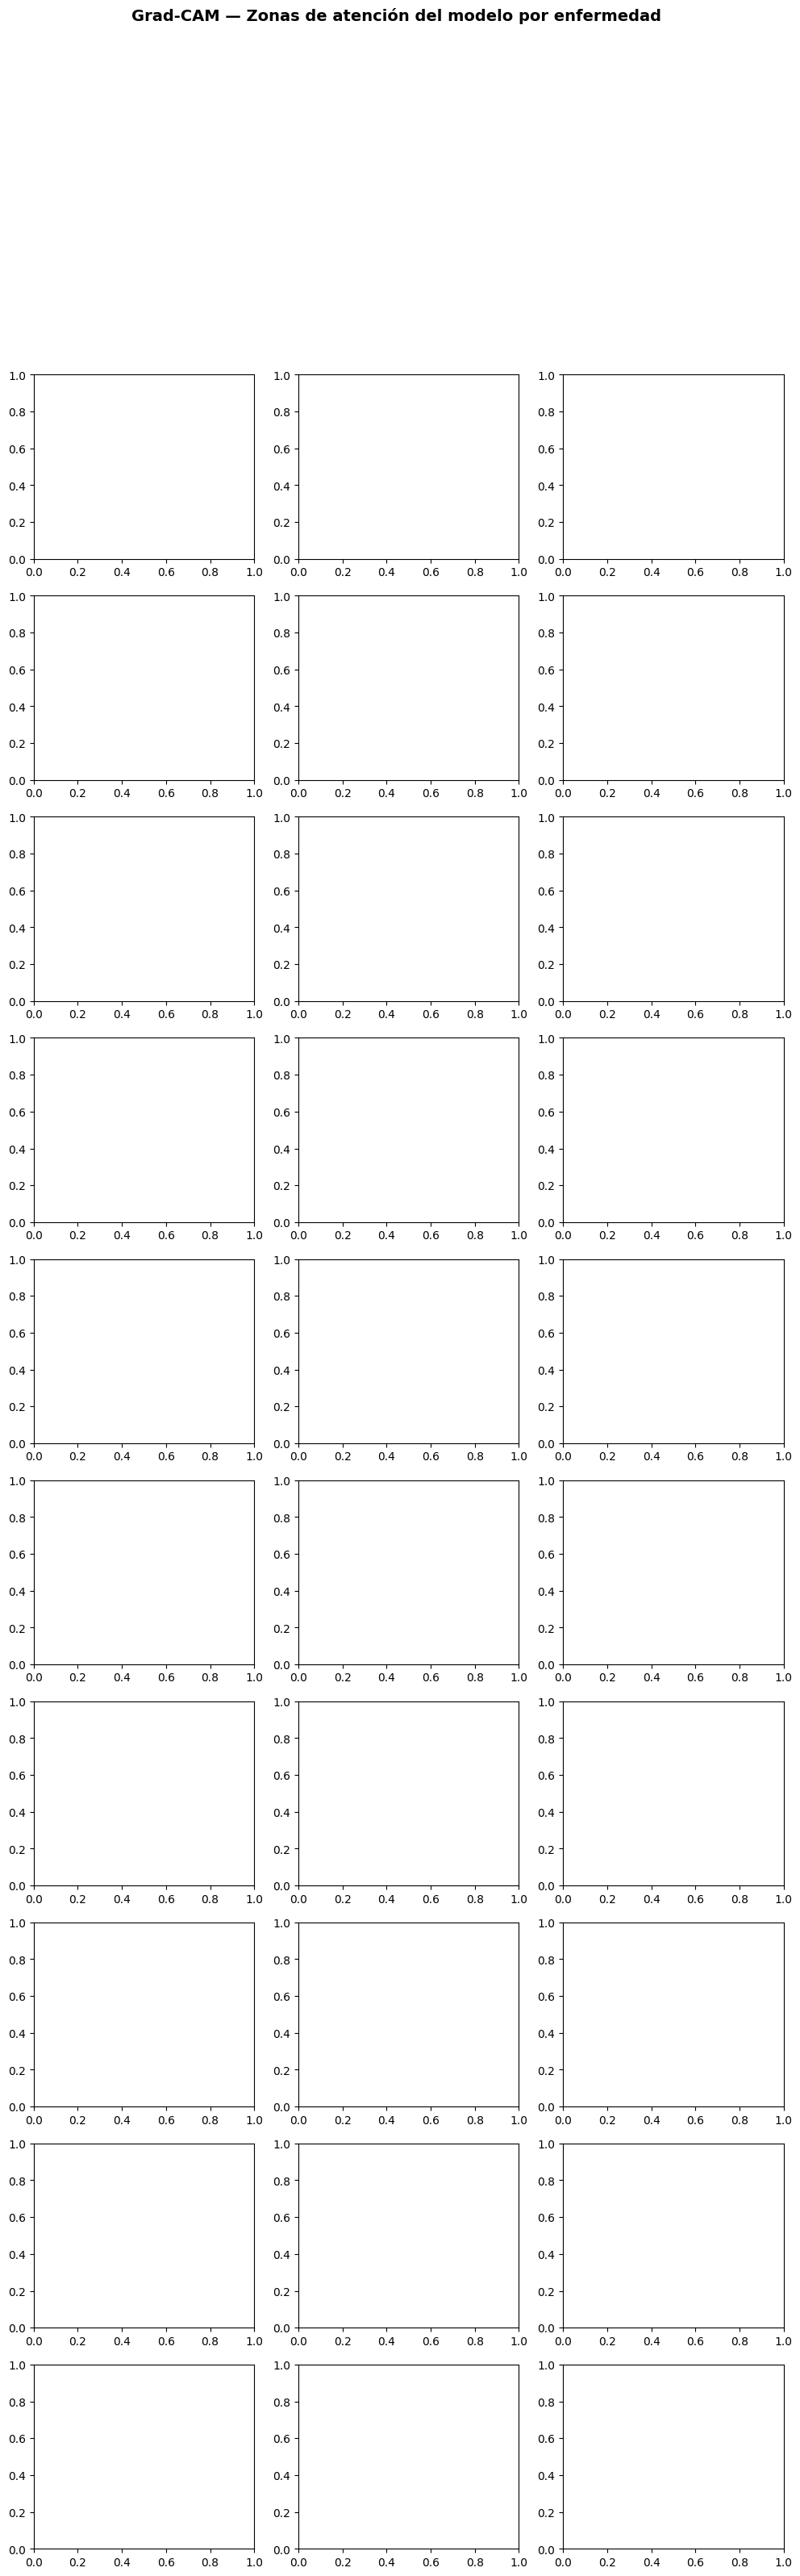

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Take an image for each class from validation set
samples = df_val.groupby("class_name").first().reset_index()

fig, axes = plt.subplots(len(samples), 3, figsize=(12, len(samples) * 3.5))
fig.suptitle("Grad-CAM — Zonas de atención del modelo por enfermedad",
             fontsize=14, fontweight="bold", y=1.01)

for i, row in samples.iterrows():
    img_path = row["image_path"]
    true_class = row["class_name"].replace("Tomato__", "")

    # Preprocess image
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Generate Grad-CAM
    heatmap, predictions = make_gradcam_heatmap(img_array, model)
    pred_index = np.argmax(predictions[0])
    pred_class = class_names[pred_index].replace("Tomato__", "")
    confidence = predictions[0][pred_index] * 100

    # Overlay
    original, superimposed = overlay_gradcam(img_path, heatmap)

    # Set title depending on result
    color = "green" if pred_class == true_class else "red"

    # Graph
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original\n{true_class}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(plt.cm.jet(heatmap)[:, :, :3])
    axes[i, 1].set_title("Heatmap", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(superimposed)
    axes[i, 2].set_title(f"Prediction: {pred_class}\nConfidence: {confidence:.1f}%",
                          fontsize=9, color=color)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("/content/data/gradcam_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grad-CAM saved in /content/data/gradcam_results.png")

In [ ]:
model.save("/content/data/tomato_disease_model.keras")
print("✅ Model saved in /content/data/tomato_disease_model.keras")

✅ Modelo guardado en /content/data/tomato_disease_model.keras


## Conclusions

- To be able to train a model which predicts accuratly one has to know the dataset. In this case the sample of images were imbalanced so if the model had been feed with raw data it would be likely that it misses those underrepresented classes.
- Models for computer vision tend to spend a lot of computer resourses and time so it is a good practice to start with a small batch of images and with a light model in order to detect any mistake as soon as possible so resourse can be well spend.